In [12]:
import torch
import numpy as np

import random
import copy
import os
import pickle

import cl_gym as cl
from metrics import MetricCollector2, FairMetricCollector
from configs import make_params

EER_dataset = ["MNIST", "FashionMNIST", "CIFAR10", "CIFAR100"]
color_list = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

# Function

In [13]:
LOG_PATH = f"scripts_output"
OUT_PATH = f"outputs"

def is_number(value):
    flag=True
    try:
        num=float(value)
        flag = num == num
    except ValueError:
        flag=False
    return flag


def load(dataset, seed, epoch, lr, tau, alpha, lmbd, method, fair_metric, eps=None, randinx = False, verbose=2):
    # if dataset == "CIFAR10":
    #     dataset+="(prev)"
    path = f"dataset={dataset}"
    if randinx:
        path+="_randidx"
    if eps is None:
        eps = 0
    # if method != "FSW":
    #     fair_metric = "no_metrics"
    path = os.path.join(path, method)
    path = os.path.join(path, fair_metric)

    # Get log_path
    runs = list()
    for d in os.listdir(os.path.join(LOG_PATH, path)):
        info_dict = dict()
        info_dict['path'] = d
        # print(f"{d=}")
        for elem in d.split("_"):
            k, v = elem.split("=")
            info_dict[k] = int(v) if v.isdigit() else float(v) if is_number(v) else v
            info_dict['path'] = d
        runs.append(info_dict)
    avails = list()
    for run in runs:
        seed_flag = seed == run.get("seed", None)
        epoch_flag = epoch == run.get("epoch", None)
        lr_flag = lr == run.get("lr", None)
        tau_flag = tau == run.get("tau", 0)
        alpha_flag = alpha == run.get("alpha", 0)
        lmbd_flag = lmbd == run.get("lmbd", 0)
        eps_flag = eps == run.get("eps", 0)
        flag = seed_flag & epoch_flag & lr_flag & tau_flag & alpha_flag & lmbd_flag & eps_flag
        if flag:
            avails.append(run)
    
    if len(avails) == 0:
        if verbose > 2:
            print(runs)
        return False
    target = avails[0]
    
    log_path = os.path.join(path, target['path'])

    out = os.path.join(os.path.join(LOG_PATH, log_path), "log.out")
    err = os.path.join(os.path.join(LOG_PATH, log_path), "log.err")
    if os.path.exists(err):
        with open(err, "r") as f:
            lines = f.readlines()
        if len(lines) and len(lines) not in [2, 5]:
            print(f"{len(lines)=}")
            if verbose:
                print(f"Error in {err} - error during running")
                for line in lines:
                    # print(line)
                    pass
            return False
    else:
        if verbose:
            print(f"error in {os.path.join(LOG_PATH, path)} - not exists")
        return False
    if os.path.exists(out):
        with open(out, "r") as f:
            lines = f.readlines()
        if len(lines) == 0:
            if verbose:
                print(f"{os.path.join(LOG_PATH, path)} - currently running")
            return False
        
    # Get out_path
    runs = list()
    for d in os.listdir(os.path.join(OUT_PATH, path)):
        info_dict = dict()
        info_dict['path'] = d
        # print(f"{d=}")
        for elem in d.split("_"):
            k, v = elem.split("=")
            info_dict[k] = int(v) if v.isdigit() else float(v) if is_number(v) else v
            info_dict['path'] = d
        runs.append(info_dict)

    avails = list()
    for run in runs:
        seed_flag = seed == run.get("seed", None)
        epoch_flag = epoch == run.get("epoch", None)
        lr_flag = lr == run.get("lr", None)
        tau_flag = tau == run.get("tau", 0)
        alpha_flag = alpha == run.get("alpha", 0)
        lmbd_flag = lmbd == run.get("lmbd", 0)
        eps_flag = eps == run.get("eps", 0)
        flag = seed_flag & epoch_flag & lr_flag & tau_flag & alpha_flag & lmbd_flag & eps_flag
        if flag:
            avails.append(run)
    if len(avails) == 0:
        if verbose > 2:
            print(runs)
        return False
    target = avails[0]
    out_path = os.path.join(path, target['path'])
    return out_path

def print_log(path, option='err'):
    out = os.path.join(os.path.join(LOG_PATH, path), "log.out")
    err = os.path.join(os.path.join(LOG_PATH, path), "log.err")    
    if option == "err":
        if os.path.exists(err):
            with open(out, "r") as f:
                lines = f.readlines()
                print(lines)
    elif option == "out":
        if os.path.exists(out):
            with open(out, "r") as f:
                lines = f.readlines()
                print(lines)

def load_metrics(path, verbose=0):
    metrics_dir = os.path.join(os.path.join(OUT_PATH, path), "metrics/metrics.pickle")
    try:
        with open(metrics_dir, "rb") as f:
            metric_manager_callback = pickle.load(f)
    except:
        # print(f"{path} still running")
        return -1

    if verbose>0:
        print(f"{metric_manager_callback.meters.keys()}")
    return metric_manager_callback

In [14]:
def get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, \
             method, eps_range = None, randinx = False, verbose=1, metric=None):
    randinx = False
    acc_list = list()
    fair_list = list()
    fair_2_list = list()
    info_list = list()

    acc_data_list = list()
    fair_data_list = list()

    if eps_range is None:
        eps_range = [0.0]

    if dataset in EER_dataset:
        disp_metric = "EER"
        disp_metric2 = "EER"
        metric = "EER"
    else:
        if metric is None or metric == "no_metrics":
            disp_metric = "EO"
            disp_metric2 = "DP"
        else:
            if metric == "EO":
                disp_metric = "EO"
                disp_metric2 = "DP"
            elif metric == "DP":
                disp_metric = "DP"
                disp_metric2 = "EO"

    # MNIST
    # if method in ['joint', 'vanilla', 'finetune']:
    if method in ['joint', 'vanilla', 'finetune', 'AGEM', "GSS", "iCaRL", "WA", "OCS", "FaIRL", "CLAD_1.0"]:
        metric = "no_metrics"
    for tau in tau_range:
        for lr in lr_range:
            for alpha in alpha_range:
                for lmbd in lambda_range:
                    for eps in eps_range:
                        cnt = 0
                        acc_temp = list()
                        acc_std_temp = list()
                        fair_temp = list()
                        fair_2_temp = list()

                        acc_data_temp = list()
                        fair_data_temp = list()
                        fair_2_data_temp = list()
                        
                        fair_std_temp = list()
                        # print(f"{info=}")
                        avail_seed = copy.deepcopy(seed_range)
                        for seed in seed_range:
                            path = load(dataset, seed, epoch, lr, tau, alpha, lmbd, method, metric, eps=eps, randinx=randinx)
                            if not path:
                                if verbose>1:
                                    print("Remove")
                                    print(f"{dataset=}, {randinx=}, {method=}, {metric=}")
                                    print(f"{seed=}, {epoch=}, {lr=}, {tau=}, {alpha=}, {lmbd=}, {eps=}")
                                avail_seed.remove(seed)
                                # print(seed)
                                # print(target_dir)
                                continue
                            mmc = load_metrics(path, verbose=verbose-1)
                            if mmc == -1:
                                continue
                            acc_temp.append(np.mean(mmc.meters['accuracy'].compute_overall()))
                            fair_temp.append(np.mean(mmc.meters[disp_metric].compute_overall()))
                            fair_2_temp.append(np.mean(mmc.meters[disp_metric2].compute_overall()))
                            acc_data_temp.append(mmc.meters['accuracy'].get_data())
                            fair_data_temp.append(mmc.meters[disp_metric].get_data())
                            # print(f"{mmc.meters[disp_metric].get_data()=}")
                            fair_2_data_temp.append(mmc.meters[disp_metric2].get_data())
                            cnt+=1
                        info = f"lr={lr}_tau={tau}_alpha_{alpha}_lmbd={lmbd}_eps={eps}({cnt=}, {avail_seed})"
                        if cnt == 0:
                            print(f"{info=}: check if boom?")
                            continue
                        else:
                            acc_mean = np.mean(acc_temp)
                            acc_std = np.std(acc_temp)
                            fair_mean = np.mean(fair_temp)
                            fair_std = np.std(fair_temp)
                            fair_2_mean = np.mean(fair_2_temp)
                            fair_2_std = np.std(fair_2_temp)

                            # acc_data_mean = np.round(np.mean(acc_data_temp, axis=0), 3)
                            # fair_data_mean = np.round(np.mean(fair_data_temp, axis=0), 3)
                            # fair_2_data_mean = np.round(np.mean(fair_2_data_temp, axis=0), 3)

                            # acc_data_list.append(acc_data_mean)
                            # fair_data_list.append(fair_data_mean)

                            info_list.append(info)
                            acc_list.append(acc_mean)
                            fair_list.append(fair_mean)
                            fair_2_list.append(fair_2_mean)
                            out = f"{info}\nacc:{np.round(acc_mean, 3)}±{np.round(acc_std,3 )}\nfair:{np.round(fair_mean, 3)}±{np.round(fair_std, 3)}"
                            # if dataset not in EER_dataset:
                            #     out+=f"\nfair2:{fair_2_mean}±{fair_2_std}"
                            if verbose:
                                print(out)
    if verbose:
        print()

    return info_list, acc_list, fair_list, fair_2_list, acc_data_list, fair_data_list


In [15]:
import matplotlib.pyplot as plt

def plot(acc_list, fair_list, marker = "o"):
    plt.plot(acc_list, fair_list, marker=marker, s = 10)
    plt.xlabel('Accuracy')
    plt.ylabel('fairness')

In [16]:
colors = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6']
labels = ["iCaRL", "WA", "CLAD_1.0", "GSS", "OCS", "FaIRL", "FSW"]
labels_disp = ["iCaRL", "WA", "CLAD", "GSS", "OCS", "FaIRL", "FSW"]


In [46]:
def draw_plot(acc_list, fair_list, method, rate = 1.5):
    markers = ["o", "^", 'D', "s", "P", "X", "*"]
    markersize = [s*rate*1.33 for s in [3.5, 4, 3, 3.5, 4, 4.5, 5.5]]
    colors = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6']
    labels = ["iCaRL", "WA", "CLAD_1.0", "GSS", "OCS", "FaIRL", "FSW"]
    labels_disp = ["iCaRL", "WA", "CLAD", "GSS", "OCS", "FaIRL", "FSW"]
    method_mapper = dict(zip(labels, labels_disp))
    color_mapper = dict(zip(labels, colors))
    markers_mapper = dict(zip(labels, markers))
    markersize_mapper = dict(zip(labels, markersize))
    plt.rcParams["font.family"] = "Times New Roman"
    plt.rcParams['pdf.fonttype'] = 42
    plt.rc('font', size=25*rate)
    # plt.rc('axes', labelsize=25*1.5)
    plt.rc('axes', labelsize=25*rate)
    plt.rc('xtick', labelsize=25*rate)
    plt.rc('ytick', labelsize=25*rate)
    # plt.xticks(np.arange(1, len(avg_data[0])+1, 1))
    plt.rc('legend', fontsize=20*rate)
    plt.rc('figure', titlesize=25*rate)
    plt.plot(acc_list, fair_list, marker=markers_mapper[method], markersize=markersize_mapper[method]*2, color = color_mapper[method], label=method_mapper[method])


# Main Result

## MNIST - EER

method='iCaRL'
lr=0.1_tau=1.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.918±0.005
fair:0.048±0.003
lr=0.01_tau=1.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.913±0.001
fair:0.048±0.002

method='WA'
lr=0.01_tau=1.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.911±0.007
fair:0.052±0.006
lr=0.001_tau=1.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.9±0.006
fair:0.051±0.004

method='CLAD_1.0'
lr=0.001_tau=1.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.835±0.016
fair:0.099±0.016

method='GSS'
lr=0.001_tau=10.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.889±0.01
fair:0.08±0.009

lr=0.01_tau=1.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.875±0.006
fair:0.072±0.006

method='OCS'
lr=0.001_tau=10.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.929±0.002
fair:0.04±0.003

method='FSW'
lr=0.001_tau=10.0_alpha_0.0005_lmbd=1.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.924±0.003
fair:0.032±0.005
lr=0.

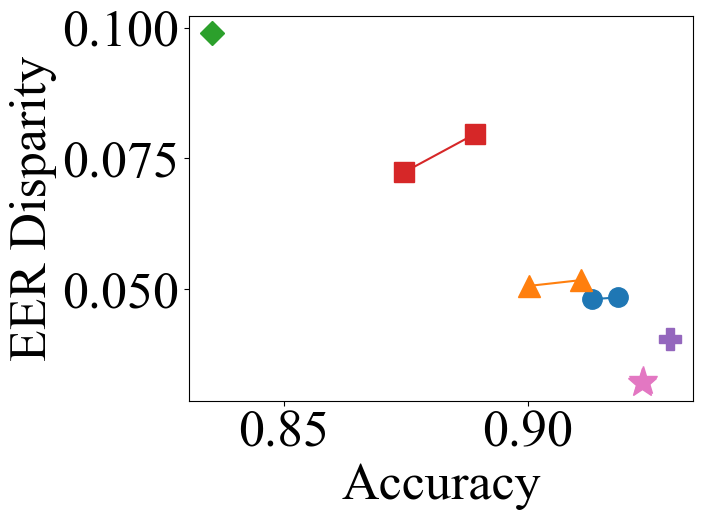

In [47]:
dataset = "MNIST"
seed_range = [0, 1, 2, 3, 4]
epoch = 5
metric="EER"
plt.figure(figsize=(6.5, 5))

lr_range = [0.1]
tau_range = [0.0]
alpha_range = [0.0]
lambda_range = [0.0]
lr_range = [0.1, 0.01]
tau_range = [1.0]
method = "iCaRL"
print(f"{method=}")
info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
draw_plot(acc_list, fair_list, method)

lr_range = [0.01, 0.001]
tau_range = [1.0]
method = "WA"
print(f"{method=}")
info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
draw_plot(acc_list, fair_list, method)

lr_range = [0.001]
tau_range = [1.0]
method = "CLAD_1.0"
print(f"{method=}")
info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
draw_plot(acc_list, fair_list, method)

lr_range = [0.001]
tau_range = [10.0]
method = "GSS"
print(f"{method=}")
info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
lr_range = [0.01]
tau_range = [1.0]
info_list_1, acc_list_1, fair_list_1, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
info_list+=info_list_1
acc_list+=acc_list_1
fair_list+=fair_list_1
draw_plot(acc_list, fair_list, method)

lr_range = [0.001]
tau_range = [10.0]
method = "OCS"
print(f"{method=}")
info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
draw_plot(acc_list, fair_list, method)

# lr_range = [0.001]
# tau_range = [0.0]
# method = "FaIRL"
# print(f"{method=}")
# info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
# draw_plot(acc_list, fair_list, method)

lr_range = [0.001]
tau_range = [10.0]
alpha_range = [0.0005]
lambda_range = [1.0, 0.5]
method = "FSW"
print(f"{method=}")
info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
draw_plot(acc_list, fair_list, method)

plt.xlabel('Accuracy')
plt.ylabel('EER Disparity')
plt.plot()
# plt.savefig(f"figs/tradeoff/{dataset}_{metric}.pdf", bbox_inches="tight")
plt.savefig(f"figs/tradeoff/{dataset}_{metric}_main_large_3.pdf", bbox_inches="tight")



## FashionMNIST - EER

method='iCaRL'
lr=0.1_tau=1.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.86±0.004
fair:0.058±0.002
lr=0.01_tau=1.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.852±0.002
fair:0.047±0.001

method='WA'
lr=0.001_tau=1.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.809±0.005
fair:0.088±0.003

method='CLAD_1.0'
lr=0.001_tau=1.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.782±0.018
fair:0.118±0.022

method='GSS'
lr=0.001_tau=5.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.732±0.021
fair:0.149±0.019

method='OCS'
lr=0.01_tau=10.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.799±0.008
fair:0.109±0.007

method='FSW'
lr=0.001_tau=10.0_alpha_0.001_lmbd=0.1_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.824±0.006
fair:0.039±0.006

method='FSW'
lr=0.001_tau=5.0_alpha_0.0005_lmbd=1.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.831±0.007
fair:0.044±0.013

method='FSW'
info='lr=0.001_tau=10.0_alpha_0.0005_lmbd=0.01_eps=0.0(cnt=0, [])': check

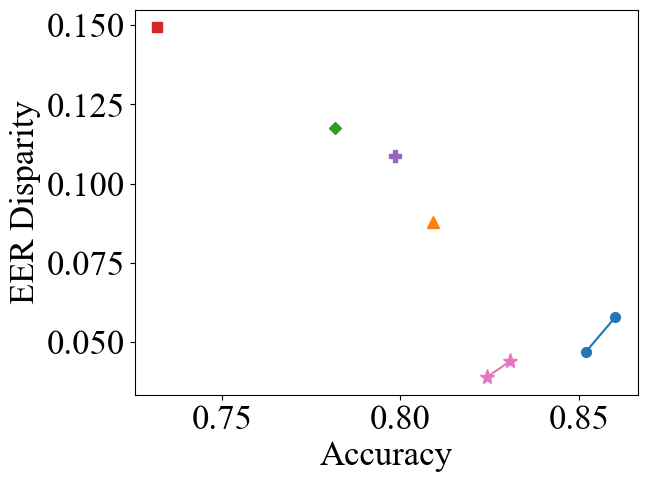

In [19]:
dataset = "FashionMNIST"
seed_range = [0, 1, 2, 3, 4]
epoch = 5
metric="EER"
plt.figure(figsize=(6.5, 5))

alpha_range = [0.0]
lambda_range = [0.0]
lr_range = [0.1, 0.01]
tau_range = [1.0]
method = "iCaRL"
print(f"{method=}")
info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
draw_plot(acc_list, fair_list, method)

lr_range = [0.001]
tau_range = [1.0]
method = "WA"
print(f"{method=}")
info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
draw_plot(acc_list, fair_list, method)

lr_range = [0.001]
tau_range = [1.0]
method = "CLAD_1.0"
print(f"{method=}")
info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
draw_plot(acc_list, fair_list, method)

lr_range = [0.001]
tau_range = [5.0]
method = "GSS"
print(f"{method=}")
info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
draw_plot(acc_list, fair_list, method)

lr_range = [0.01]
tau_range = [10.0]
method = "OCS"
print(f"{method=}")
info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
draw_plot(acc_list, fair_list, method)

# lmbd 0.1
lr_range = [0.001]
tau_range = [10.0]
alpha_range = [0.001]
lambda_range = [0.1]
method = "FSW"
print(f"{method=}")
info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)

# lambda 1
lr_range = [0.001]
tau_range = [5.0]
alpha_range = [0.0005]
lambda_range = [1.0]
method = "FSW"
print(f"{method=}")
info_list_1, acc_list_1, fair_list_1, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
info_list+=info_list_1
acc_list+=acc_list_1
fair_list+=fair_list_1

# lambda 0.01
lr_range = [0.001]
tau_range = [10.0]
alpha_range = [0.0005]
lambda_range = [0.01]
method = "FSW"
print(f"{method=}")
info_list_1, acc_list_1, fair_list_1, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
info_list+=info_list_1
acc_list+=acc_list_1
fair_list+=fair_list_1
draw_plot(acc_list, fair_list, method)

plt.xlabel('Accuracy')
plt.ylabel('EER Disparity')


plt.savefig(f"figs/tradeoff/{dataset}_{metric}.pdf", bbox_inches="tight")



## BiasedMNIST EO

method='iCaRL'
lr=0.1_tau=1.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.802±0.008
fair:0.365±0.021

method='WA'
lr=0.01_tau=1.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.916±0.002
fair:0.14±0.004

method='CLAD_1.0'
lr=0.001_tau=1.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.871±0.012
fair:0.198±0.022
lr=0.01_tau=1.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.705±0.126
fair:0.174±0.052

method='GSS'
lr=0.001_tau=5.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.809±0.005
fair:0.325±0.017
lr=0.001_tau=1.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.809±0.009
fair:0.332±0.021

method='OCS'
lr=0.001_tau=10.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.824±0.007
fair:0.331±0.013

method='FSW'
lr=0.001_tau=10.0_alpha_0.0005_lmbd=0.5_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.909±0.004
fair:0.119±0.007



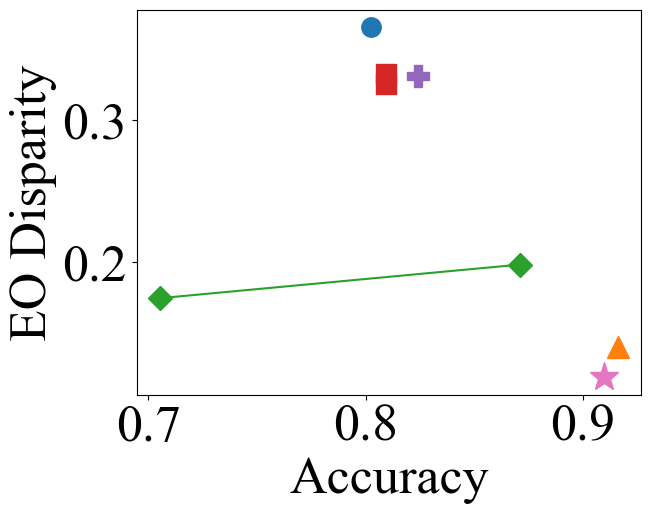

In [48]:
dataset = "BiasedMNIST"
seed_range = [0, 1, 2, 3, 4]
epoch = 15
metric="EO"
plt.figure(figsize=(6.5, 5))

alpha_range = [0.0]
lambda_range = [0.0]


lr_range = [0.1]
tau_range = [1.0]
method = "iCaRL"
print(f"{method=}")
info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
draw_plot(acc_list, fair_list, method)

lr_range = [0.01]
tau_range = [1.0]
method = "WA"
print(f"{method=}")
info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
draw_plot(acc_list, fair_list, method)

lr_range = [0.001, 0.01]
tau_range = [1.0]
method = "CLAD_1.0"
print(f"{method=}")
info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
draw_plot(acc_list, fair_list, method)

lr_range = [0.001]
tau_range = [5.0, 1.0]
method = "GSS"
print(f"{method=}")
info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
draw_plot(acc_list, fair_list, method)

lr_range = [0.001]
tau_range = [10.0]
method = "OCS"
print(f"{method=}")
info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
draw_plot(acc_list, fair_list, method)

# lr_range = [0.01]
# tau_range = [0.0]
# method = "FaIRL"
# print(f"{method=}")
# info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
# draw_plot(acc_list, fair_list, method)

lr_range = [0.001]
tau_range = [10.0]
alpha_range = [0.0005]
lambda_range = [0.5]
method = "FSW"
print(f"{method=}")
info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
draw_plot(acc_list, fair_list, method)



plt.xlabel('Accuracy')
plt.ylabel('EO Disparity')


# plt.savefig(f"figs/tradeoff/{dataset}_{metric}.pdf", bbox_inches="tight")
plt.savefig(f"figs/tradeoff/{dataset}_{metric}_main_large_3.pdf", bbox_inches="tight")



## BiasedMNIST DP

method='iCaRL'
lr=0.1_tau=1.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.802±0.008
fair:0.015±0.001

method='CLAD_1.0'
lr=0.001_tau=1.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.871±0.012
fair:0.013±0.001

method='GSS'
lr=0.001_tau=5.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.809±0.005
fair:0.039±0.003
lr=0.001_tau=1.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.809±0.009
fair:0.041±0.003

method='OCS'
lr=0.001_tau=10.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.824±0.007
fair:0.035±0.003

method='FSW'
lr=0.001_tau=10.0_alpha_0.002_lmbd=0.1_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.904±0.004
fair:0.008±0.001

method='FSW'
lr=0.001_tau=10.0_alpha_0.0005_lmbd=0.5_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.909±0.004
fair:0.009±0.001



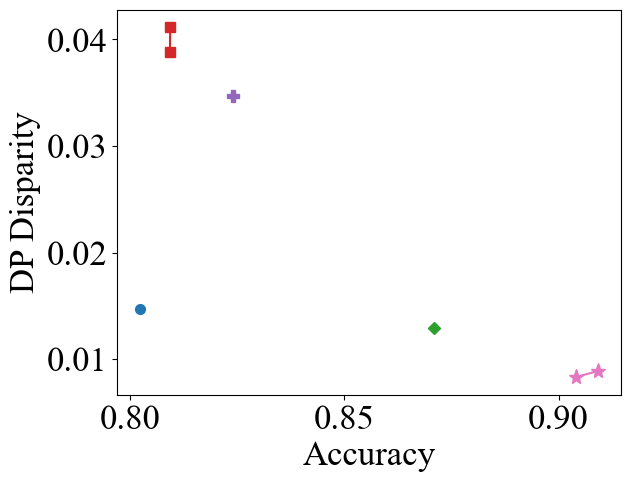

In [21]:
dataset = "BiasedMNIST"
seed_range = [0, 1, 2, 3, 4]
epoch = 15
metric="DP"
plt.figure(figsize=(6.5, 5))

alpha_range = [0.0]
lambda_range = [0.0]

lr_range = [0.1]
tau_range = [1.0]
method = "iCaRL"
print(f"{method=}")
info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
draw_plot(acc_list, fair_list, method)

lr_range = [0.001]
tau_range = [1.0]
method = "CLAD_1.0"
print(f"{method=}")
info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
draw_plot(acc_list, fair_list, method)

lr_range = [0.001]
tau_range = [5.0, 1.0]
method = "GSS"
print(f"{method=}")
info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
draw_plot(acc_list, fair_list, method)

lr_range = [0.001]
tau_range = [10.0]
method = "OCS"
print(f"{method=}")
info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
draw_plot(acc_list, fair_list, method)


lr_range = [0.001]
tau_range = [10.0]
alpha_range = [0.002]
lambda_range = [0.1]
method = "FSW"
print(f"{method=}")
info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)

# lambda 1.0
lr_range = [0.001]
tau_range = [10.0]
alpha_range = [0.0005]
lambda_range = [0.5]
method = "FSW"
print(f"{method=}")
info_list_1, acc_list_1, fair_list_1, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
info_list+=info_list_1
acc_list+=acc_list_1
fair_list+=fair_list_1
draw_plot(acc_list, fair_list, method)



plt.xlabel('Accuracy')
plt.ylabel('DP Disparity')

plt.savefig(f"figs/tradeoff/{dataset}_{metric}.pdf", bbox_inches="tight")



## Drug EO

method='iCaRL'
lr=0.1_tau=1.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.463±0.016
fair:0.225±0.069
lr=0.01_tau=1.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.448±0.022
fair:0.2±0.018
lr=0.001_tau=1.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.444±0.025
fair:0.19±0.017

method='WA'
lr=0.01_tau=1.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.438±0.019
fair:0.149±0.051
lr=0.1_tau=1.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.408±0.022
fair:0.134±0.029
lr=0.001_tau=1.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.363±0.008
fair:0.073±0.017

method='CLAD_1.0'
lr=0.01_tau=1.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.41±0.026
fair:0.114±0.043
lr=0.1_tau=1.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.375±0.022
fair:0.106±0.018
lr=0.001_tau=1.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.369±0.019
fair:0.044±0.014

method='GSS'
lr=0.001_tau=1.0_alpha_0.0_lmbd=0.0_eps=0.0

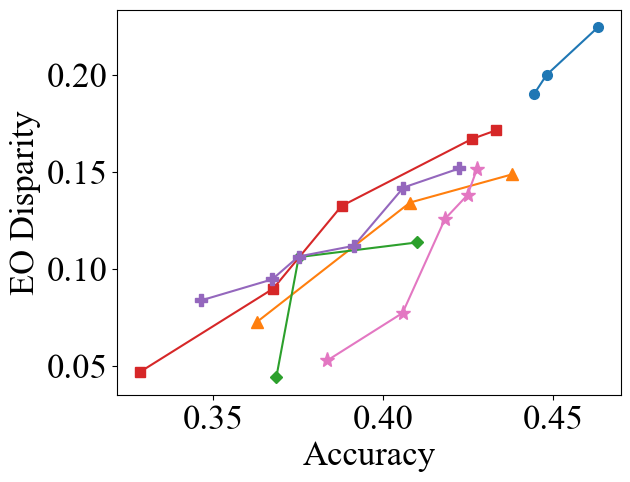

In [22]:
dataset = "Drug"
seed_range = [0, 1, 2, 3, 4]
epoch = 25
metric="EO"
plt.figure(figsize=(6.5, 5))

alpha_range = [0.0]
lambda_range = [0.0]


lr_range = [0.1, 0.01, 0.001]
tau_range = [1.0]
method = "iCaRL"
print(f"{method=}")
info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
draw_plot(acc_list, fair_list, method)

lr_range = [0.01, 0.1, 0.001]
tau_range = [1.0]
method = "WA"
print(f"{method=}")
info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
draw_plot(acc_list, fair_list, method)

lr_range = [0.01, 0.1, 0.001]
tau_range = [1.0]
method = "CLAD_1.0"
print(f"{method=}")
info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
draw_plot(acc_list, fair_list, method)

lr_range = [0.001]
tau_range = [1.0, 5.0]
method = "GSS"
print(f"{method=}")
info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
lr_range = [0.01]
tau_range = [1.0]
print(f"{method=}")
info_list_1, acc_list_1, fair_list_1, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
info_list+=info_list_1
acc_list+=acc_list_1
fair_list+=fair_list_1
lr_range = [0.1]
tau_range = [1.0, 5.0]
print(f"{method=}")
info_list_1, acc_list_1, fair_list_1, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
info_list+=info_list_1
acc_list+=acc_list_1
fair_list+=fair_list_1
draw_plot(acc_list, fair_list, method)


lr_range = [0.01]
tau_range = [10.0, 5.0]
method = "OCS"
print(f"{method=}")
info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
lr_range = [0.1]
tau_range = [5.0, 1.0]
print(f"{method=}")
info_list_1, acc_list_1, fair_list_1, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
info_list+=info_list_1
acc_list+=acc_list_1
fair_list+=fair_list_1
lr_range = [0.001]
tau_range = [5.0, 1.0]
print(f"{method=}")
info_list_1, acc_list_1, fair_list_1, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
info_list+=info_list_1
acc_list+=acc_list_1
fair_list+=fair_list_1
draw_plot(acc_list, fair_list, method)


lr_range = [0.001]
tau_range = [5.0]
alpha_range = [0.0005]
lambda_range = [0.5]
method = "FSW"
print(f"{method=}")
info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)


lr_range = [0.001]
tau_range = [1.0]
alpha_range = [0.002]
lambda_range = [0.1]
method = "FSW"
print(f"{method=}")
info_list_1, acc_list_1, fair_list_1, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
info_list+=info_list_1
acc_list+=acc_list_1
fair_list+=fair_list_1

lr_range = [0.01]
tau_range = [2.0]
alpha_range = [0.01]
lambda_range = [0.1]
method = "FSW"
print(f"{method=}")
info_list_1, acc_list_1, fair_list_1, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
info_list+=info_list_1
acc_list+=acc_list_1
fair_list+=fair_list_1

lr_range = [0.01]
tau_range = [1.0]
alpha_range = [0.0005]
lambda_range = [0.1]
method = "FSW"
print(f"{method=}")
info_list_1, acc_list_1, fair_list_1, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
info_list+=info_list_1
acc_list+=acc_list_1
fair_list+=fair_list_1

lr_range = [0.01]
tau_range = [1.0]
alpha_range = [0.01]
lambda_range = [1.0]
method = "FSW"
print(f"{method=}")
info_list_1, acc_list_1, fair_list_1, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
info_list+=info_list_1
acc_list+=acc_list_1
fair_list+=fair_list_1

draw_plot(acc_list, fair_list, method)



plt.xlabel('Accuracy')
plt.ylabel('EO Disparity')

plt.savefig(f"figs/tradeoff/{dataset}_{metric}.pdf", bbox_inches="tight")




## Drug DP

method='iCaRL'
lr=0.1_tau=1.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.463±0.016
fair:0.098±0.023
lr=0.001_tau=1.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.444±0.025
fair:0.093±0.009

method='WA'
lr=0.01_tau=1.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.438±0.019
fair:0.082±0.021
lr=0.1_tau=1.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.408±0.022
fair:0.067±0.013
lr=0.001_tau=1.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.363±0.008
fair:0.06±0.005

method='CLAD_1.0'
lr=0.01_tau=1.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.41±0.026
fair:0.069±0.019
lr=0.1_tau=1.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.375±0.022
fair:0.047±0.011
lr=0.001_tau=1.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.369±0.019
fair:0.043±0.013

method='GSS'
lr=0.001_tau=1.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.433±0.009
fair:0.08±0.016
lr=0.001_tau=5.0_alpha_0.0_lmbd=0.0_eps=0

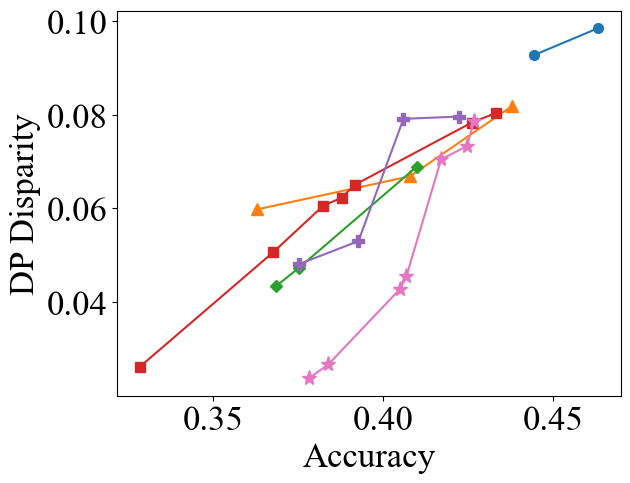

In [23]:
dataset = "Drug"
seed_range = [0, 1, 2, 3, 4]
epoch = 25
metric="DP"
plt.figure(figsize=(6.5, 5))

alpha_range = [0.0]
lambda_range = [0.0]


lr_range = [0.1, 0.001]
tau_range = [1.0]
method = "iCaRL"
print(f"{method=}")
info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
draw_plot(acc_list, fair_list, method)

lr_range = [0.01, 0.1, 0.001]
tau_range = [1.0]
method = "WA"
print(f"{method=}")
info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
draw_plot(acc_list, fair_list, method)

lr_range = [0.01, 0.1, 0.001]
tau_range = [1.0]
method = "CLAD_1.0"
print(f"{method=}")
info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
draw_plot(acc_list, fair_list, method)

lr_range = [0.001]
tau_range = [1.0, 5.0]
method = "GSS"
print(f"{method=}")
info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
lr_range = [0.01]
tau_range = [5.0, 1.0, 10.0]
print(f"{method=}")
info_list_1, acc_list_1, fair_list_1, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
info_list+=info_list_1
acc_list+=acc_list_1
fair_list+=fair_list_1
lr_range = [0.1]
tau_range = [1.0, 5.0]
print(f"{method=}")
info_list_1, acc_list_1, fair_list_1, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
info_list+=info_list_1
acc_list+=acc_list_1
fair_list+=fair_list_1
draw_plot(acc_list, fair_list, method)

lr_range = [0.01]
tau_range = [10.0, 5.0]
method = "OCS"
print(f"{method=}")
info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
lr_range = [0.1]
tau_range = [10.0, 1.0]
print(f"{method=}")
info_list_1, acc_list_1, fair_list_1, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
info_list+=info_list_1
acc_list+=acc_list_1
fair_list+=fair_list_1

draw_plot(acc_list, fair_list, method)


lr_range = [0.001]
tau_range = [5.0]
alpha_range = [0.01, 0.002]
lambda_range = [0.1]
method = "FSW"
print(f"{method=}")
info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)

lr_range = [0.001]
tau_range = [1.0]
alpha_range = [0.01]
lambda_range = [0.5]
method = "FSW"
print(f"{method=}")
info_list_1, acc_list_1, fair_list_1, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
info_list+=info_list_1
acc_list+=acc_list_1
fair_list+=fair_list_1

lr_range = [0.001]
tau_range = [1.0]
alpha_range = [0.001]
lambda_range = [0.1]
method = "FSW"
print(f"{method=}")
info_list_1, acc_list_1, fair_list_1, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
info_list+=info_list_1
acc_list+=acc_list_1
fair_list+=fair_list_1

lr_range = [0.01]
tau_range = [10.0]
alpha_range = [0.01]
lambda_range = [1.0]
method = "FSW"
print(f"{method=}")
info_list_1, acc_list_1, fair_list_1, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
info_list+=info_list_1
acc_list+=acc_list_1
fair_list+=fair_list_1

lr_range = [0.01]
tau_range = [1.0]
alpha_range = [0.01]
lambda_range = [0.1]
method = "FSW"
print(f"{method=}")
info_list_1, acc_list_1, fair_list_1, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
info_list+=info_list_1
acc_list+=acc_list_1
fair_list+=fair_list_1

lr_range = [0.01]
tau_range = [1.0]
alpha_range = [0.0005]
lambda_range = [0.5]
method = "FSW"
print(f"{method=}")
info_list_1, acc_list_1, fair_list_1, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
info_list+=info_list_1
acc_list+=acc_list_1
fair_list+=fair_list_1

draw_plot(acc_list, fair_list, method)


plt.xlabel('Accuracy')
plt.ylabel('DP Disparity')

plt.savefig(f"figs/tradeoff/{dataset}_{metric}.pdf", bbox_inches="tight")




## Bios EO

method='iCaRL'
lr=0.001_tau=1.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.829±0.002
fair:0.084±0.003

method='WA'
lr=2e-05_tau=1.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.74±0.005
fair:0.063±0.002
lr=0.0001_tau=1.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.796±0.003
fair:0.076±0.001

method='CLAD_1.0'
lr=2e-05_tau=1.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.799±0.003
fair:0.074±0.002

method='GSS'
lr=2e-05_tau=5.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.808±0.003
fair:0.081±0.002

method='FSW'
lr=2e-05_tau=10.0_alpha_0.01_lmbd=1.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.682±0.009
fair:0.049±0.003
lr=2e-05_tau=1.0_alpha_0.01_lmbd=1.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.705±0.009
fair:0.056±0.005
lr=2e-05_tau=2.0_alpha_0.01_lmbd=1.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.717±0.007
fair:0.061±0.005

method='FSW'
lr=2e-05_tau=5.0_alpha_0.002_lmbd=1.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.803±0.005
fair:0.068±0.

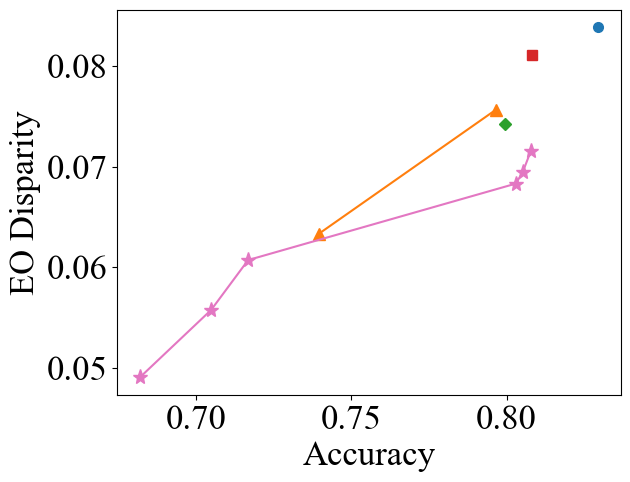

In [24]:
dataset = "Bios_128"
seed_range = [0, 1, 2, 3, 4]
epoch = 10
metric="EO"
plt.figure(figsize=(6.5, 5))

alpha_range = [0.0]
lambda_range = [0.0]


lr_range = [0.001]
tau_range = [1.0]
method = "iCaRL"
print(f"{method=}")
info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
draw_plot(acc_list, fair_list, method)

lr_range = [2e-5, 0.0001]
tau_range = [1.0]
method = "WA"
print(f"{method=}")
info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
draw_plot(acc_list, fair_list, method)

lr_range = [2e-5]
tau_range = [1.0]
method = "CLAD_1.0"
print(f"{method=}")
info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
draw_plot(acc_list, fair_list, method)

lr_range = [2e-5]
tau_range = [5.0]
method = "GSS"
print(f"{method=}")
info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
draw_plot(acc_list, fair_list, method)

lr_range = [2e-5]
tau_range = [10.0, 1.0, 2.0]
alpha_range = [0.01]
lambda_range = [1.0]
method = "FSW"
print(f"{method=}")
info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)

# running for more lambda
lr_range = [2e-5]
tau_range = [5.0]
alpha_range = [0.002]
lambda_range = [1.0]
method = "FSW"
print(f"{method=}")
info_list_1, acc_list_1, fair_list_1, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
info_list+=info_list_1
acc_list+=acc_list_1
fair_list+=fair_list_1

lr_range = [2e-5]
tau_range = [2.0]
alpha_range = [0.002]
lambda_range = [1.0]
method = "FSW"
print(f"{method=}")
info_list_1, acc_list_1, fair_list_1, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
info_list+=info_list_1
acc_list+=acc_list_1
fair_list+=fair_list_1

lr_range = [2e-5]
tau_range = [5.0]
alpha_range = [0.0005]
lambda_range = [1.0]
method = "FSW"
print(f"{method=}")
info_list_1, acc_list_1, fair_list_1, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
info_list+=info_list_1
acc_list+=acc_list_1
fair_list+=fair_list_1
draw_plot(acc_list, fair_list, method)


plt.xlabel('Accuracy')
plt.ylabel('EO Disparity')

plt.savefig(f"figs/tradeoff/{dataset}_{metric}.pdf", bbox_inches="tight")




## Bios DP

method='iCaRL'
lr=0.001_tau=1.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.829±0.002
fair:0.022±0.0

method='WA'
lr=2e-05_tau=1.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.74±0.005
fair:0.022±0.0
lr=0.0001_tau=1.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.796±0.003
fair:0.022±0.0

method='CLAD_1.0'
lr=2e-05_tau=1.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.799±0.003
fair:0.022±0.0

method='GSS'


lr=2e-05_tau=1.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.806±0.004
fair:0.023±0.0
lr=2e-05_tau=2.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.807±0.003
fair:0.023±0.0
lr=2e-05_tau=5.0_alpha_0.0_lmbd=0.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.808±0.003
fair:0.023±0.0

method='FSW'
lr=2e-05_tau=1.0_alpha_0.01_lmbd=1.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.704±0.012
fair:0.02±0.001
lr=2e-05_tau=2.0_alpha_0.01_lmbd=1.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.708±0.012
fair:0.02±0.001

method='FSW'
lr=2e-05_tau=5.0_alpha_0.002_lmbd=0.1_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.801±0.004
fair:0.021±0.0

method='FSW'
lr=2e-05_tau=2.0_alpha_0.002_lmbd=1.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.805±0.003
fair:0.022±0.0

method='FSW'
lr=2e-05_tau=10.0_alpha_0.001_lmbd=1.0_eps=0.0(cnt=5, [0, 1, 2, 3, 4])
acc:0.809±0.003
fair:0.022±0.0



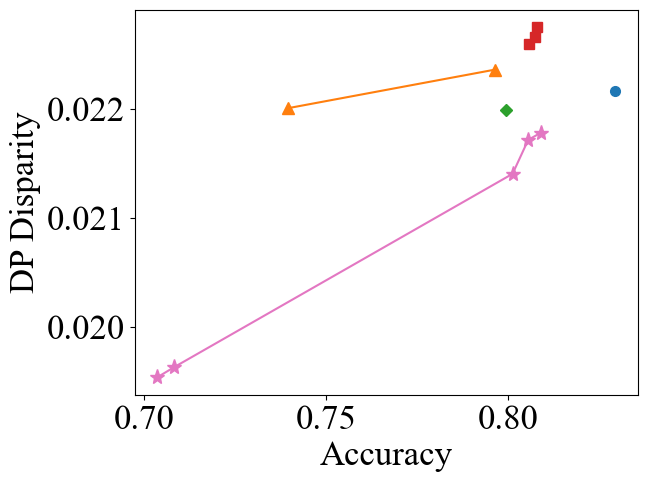

In [25]:
dataset = "Bios_128"
seed_range = [0, 1, 2, 3, 4]
epoch = 10
metric="DP"
plt.figure(figsize=(6.5, 5))

alpha_range = [0.0]
lambda_range = [0.0]

lr_range = [0.001]
tau_range = [1.0]
method = "iCaRL"
print(f"{method=}")
info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
draw_plot(acc_list, fair_list, method)

lr_range = [2e-5, 0.0001]
tau_range = [1.0]
method = "WA"
print(f"{method=}")
info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
draw_plot(acc_list, fair_list, method)

lr_range = [2e-5]
tau_range = [1.0]
method = "CLAD_1.0"
print(f"{method=}")
info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
draw_plot(acc_list, fair_list, method)

lr_range = [2e-5]
tau_range = [1.0, 2.0, 5.0]
method = "GSS"
print(f"{method=}")
info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
draw_plot(acc_list, fair_list, method)

lr_range = [2e-5]
tau_range = [1.0, 2.0]
alpha_range = [0.01]
lambda_range = [1.0]
method = "FSW"
print(f"{method=}")
info_list, acc_list, fair_list, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)

# lr_range = [2e-5]
# tau_range = [1.0]
# alpha_range = [0.01]
# lambda_range = [0.1]
# method = "FSW"
# print(f"{method=}")
# info_list_1, acc_list_1, fair_list_1, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
# info_list+=info_list_1
# acc_list+=acc_list_1
# fair_list+=fair_list_1

lr_range = [2e-5]
tau_range = [5.0]
alpha_range = [0.002]
lambda_range = [0.1]
method = "FSW"
print(f"{method=}")
info_list_1, acc_list_1, fair_list_1, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
info_list+=info_list_1
acc_list+=acc_list_1
fair_list+=fair_list_1

lr_range = [2e-5]
tau_range = [2.0]
alpha_range = [0.002]
lambda_range = [1.0]
method = "FSW"
print(f"{method=}")
info_list_1, acc_list_1, fair_list_1, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
info_list+=info_list_1
acc_list+=acc_list_1
fair_list+=fair_list_1

lr_range = [2e-5]
tau_range = [10.0]
alpha_range = [0.001]
lambda_range = [1.0]
method = "FSW"
print(f"{method=}")
info_list_1, acc_list_1, fair_list_1, *_ = get_best(dataset, seed_range, epoch, lr_range, tau_range, alpha_range, lambda_range, method, metric=metric, verbose=1)
info_list+=info_list_1
acc_list+=acc_list_1
fair_list+=fair_list_1
draw_plot(acc_list, fair_list, method)



plt.xlabel('Accuracy')
plt.ylabel('DP Disparity')


plt.savefig(f"figs/tradeoff/{dataset}_{metric}.pdf", bbox_inches="tight")

